In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import chaospy as cp
import time
from utils.config import *

## Parameters

In [2]:
ntot = 1.7e20  # total density
Vp = 150 
#cross sections at 14 keV
sigmavDT = 2.4e-22
sigmavDDn = 1.2e-24
sigmavDDp = 1.2e-24
TBRDT = 1.15
TBRDD = 0.9  # TBR for D-D plasma
lambda_T = 1.78e-9  # decay constant for tritium
tau_ofc = 1*3600*24 # 1 day
tau_ifc = 3600*4 # 4 h
tau_p_T = 1
P_aux = 250 # MW
eta_th = 0.3 # -
C_f = 0.7 # capacity factor [-]
c_dollar_per_kWh = 0.3 # electricity cost

tritium_mass = 3.016049268e-3 / 6.022e23  # kg per tritium atom (3.016 u -> kg)

# Energy released by fusion reactions
# E_DDp = 4.03*u("MeV").to("J") # [J] energy released by DDp reactions
# E_DDn = 3.46*u("MeV").to("J") # [J] energy released by DDn reactions
# E_DT = 17.6*u("MeV").to("J") # [J] energy released by DT reactions
# E_DHe3 = 18.0153*u("MeV").to("J") # [J] energy released by DHe3 reactions

## Model functions

In [3]:
def tritium_inventory_odes(t,y):
    
    N_ofc, N_ifc, N_st, nT = y
    
    def f_T_inj(t,N_st,nT):
        if N_st > nT*Vp:
            return (0.9999)
        else:
            return 0.9999 # constant injection rate, can be modified to a function of time or state variables
    
    dN_ofc_dt = TBRDT*(ntot-nT)*nT*sigmavDT*Vp + TBRDD*0.5*(ntot-nT)**2*sigmavDDn*Vp - N_ofc / tau_ofc - N_ofc*lambda_T
    dN_ifc_dt = N_ofc / tau_ofc - N_ifc / tau_ifc  - lambda_T * N_ifc + nT / tau_p_T * Vp
    dN_stor_dt = (N_ifc / tau_ifc - lambda_T * N_st )*(1 - f_T_inj(t,N_st,nT))
    dnT_dt = f_T_inj(t,N_st,nT)/Vp*((N_ifc / tau_ifc - lambda_T * N_st )) + 0.5*(ntot-nT)**2*sigmavDDp - nT/tau_p_T - (ntot-nT)*nT*sigmavDT

    return [dN_ofc_dt, dN_ifc_dt, dN_stor_dt, dnT_dt]


y0 = [0, 0, 0, 0]  # Initial conditions: [I_ofc, I_ifc, I_st, n_T]

# Time span
years_to_seconds = 365 * 24 * 3600
t_span = (0, 1000*years_to_seconds)

t_eval = np.linspace(*t_span, 10)

def DT_reached(t, y): 
    # stop when 50% D - 50% T is reached (when nT/ntot = 0.5)
    return y[3] - (0.5 * ntot)
    
# stop whe  DT reached
DT_reached.terminal = True
# Solve ODE
# sol = solve_ivp(tritium_inventory_odes, t_span, y0,method = 'BDF', events = DT_reached, dense_output=True)


def N_T_in_rate(N_st, target_rate=100e20, min_storage=0.01/tritium_mass):
    """
    Adaptive tritium injection rate that prevents storage depletion
    
    Parameters:
    - N_st: current storage inventory [particles]
    - target_rate: desired injection rate [particles/s]
    - min_storage: minimum storage to maintain [particles]
    
    Returns:
    - actual injection rate [particles/s]
    """
    if N_st <= min_storage:
        return 0.0  # No injection if storage is too low
    
    # Available storage above minimum threshold
    available_storage = N_st - min_storage
    
    # Limit injection rate to prevent depletion
    max_safe_rate = 0.5 * available_storage
    
    # Return the minimum of target rate and safe rate
    return min(target_rate, max_safe_rate)

def tritium_inventory_odes1(t,y):
    
    N_ofc, N_ifc, N_st, nT = y
    # Calculate adaptive injection rate
    injection_rate = N_T_in_rate(N_st)
    
    
    dN_ofc_dt = TBRDT*(ntot-nT)*nT*sigmavDT*Vp + TBRDD*0.5*(ntot-nT)**2*sigmavDDn*Vp - N_ofc / tau_ofc - N_ofc*lambda_T
    dN_ifc_dt = N_ofc / tau_ofc - N_ifc / tau_ifc  - lambda_T * N_ifc + nT / tau_p_T * Vp
    dN_stor_dt = N_ifc / tau_ifc - lambda_T * N_st - injection_rate
    dnT_dt = injection_rate/Vp + 0.5*(ntot-nT)**2*sigmavDDp - nT/tau_p_T - (ntot-nT)*nT*sigmavDT

    return [dN_ofc_dt, dN_ifc_dt, dN_stor_dt, dnT_dt]


y0 = [0, 0, 0, 0]  # Initial conditions: [I_ofc, I_ifc, I_st, n_T]

# Time span
years_to_seconds = 365 * 24 * 3600
t_span = (0, 10*years_to_seconds)

t_eval = np.linspace(*t_span, 10)

def DT_reached(t, y): 
    # stop when 50% D - 50% T is reached (when nT/ntot = 0.5)
    return y[3] - (0.5 * ntot)
def NEGATIVE(t, y):
    # stop when y[0] or y[1] or y[2] or y[3] is negative
    return min(y[0]+1e-10, y[1]+1e-10, y[2]+1e-10, y[3]+1e-10)

    
# stop whe  DT reached
DT_reached.terminal = True
NEGATIVE.terminal = True
# Solve ODE
sol1 = solve_ivp(tritium_inventory_odes1, t_span, y0,method = 'LSODA', events = [DT_reached, NEGATIVE], dense_output=True)


In [4]:
def sigmav_DD_BoschHale(ion_temp_profile):
    r"""Deuterium-Deuterium reaction.

    Calculate :math:`\langle \sigma v \rangle` product for a given characteristic ion energy using Bosch Hale method.

    Function tested on available data at [1, 2, 5, 10, 20, 50, 100] keV.
    Maximum error = 3.8% within range 5-50 keV and increases significantly outside of [5, 50] keV.

    Uses DD cross section formulation from :cite:`bosch_improved_1992`.

    Other form in :cite:`langenbrunner_analytic_2017`.

    Args:
        ion_temp_profile: ion temperature profile [keV]

    Returns:
        :math:`\langle \sigma v \rangle` tuple (total, D(d,p)T, D(d,n)3He) in cm^3/s.
    """
    if hasattr(ion_temp_profile, "magnitude"):
        ion_temp_profile = ion_temp_profile.magnitude
    # For D(d,n)3He
    cBH_1 = [((31.3970**2) / 4.0) ** (1.0 / 3.0), 5.65718e-12, 3.41e-03, 1.99e-03, 0, 1.05e-05, 0, 0]  # 3.72e-16,

    mc2_1 = 937814.0

    # For D(d,p)T
    cBH_2 = [((31.3970**2) / 4.0) ** (1.0 / 3.0), 5.43360e-12, 5.86e-03, 7.68e-03, 0, -2.96e-06, 0, 0]  # 3.57e-16,

    mc2_2 = 937814.0

    thetaBH_1 = ion_temp_profile / (
        1
        - (
            (cBH_1[2] * ion_temp_profile + cBH_1[4] * ion_temp_profile**2 + cBH_1[6] * ion_temp_profile**3)
            / (1 + cBH_1[3] * ion_temp_profile + cBH_1[5] * ion_temp_profile**2 + cBH_1[7] * ion_temp_profile**3)
        )
    )

    thetaBH_2 = ion_temp_profile / (
        1
        - (
            (cBH_2[2] * ion_temp_profile + cBH_2[4] * ion_temp_profile**2 + cBH_2[6] * ion_temp_profile**3)
            / (1 + cBH_2[3] * ion_temp_profile + cBH_2[5] * ion_temp_profile**2 + cBH_2[7] * ion_temp_profile**3)
        )
    )

    etaBH_1: float = cBH_1[0] / (thetaBH_1 ** (1.0 / 3.0))
    etaBH_2: float = cBH_2[0] / (thetaBH_2 ** (1.0 / 3.0))

    sigmav_1 = cBH_1[1] * thetaBH_1 * np.sqrt(etaBH_1 / (mc2_1 * (ion_temp_profile**3.0))) * np.exp(-3.0 * etaBH_1)
    sigmav_2 = cBH_2[1] * thetaBH_2 * np.sqrt(etaBH_2 / (mc2_2 * (ion_temp_profile**3.0))) * np.exp(-3.0 * etaBH_2)
    sigmav_tot = sigmav_1 + sigmav_2

    cm3tom3_per_sec = 1e-6

    sigmav_1 = sigmav_1 * cm3tom3_per_sec  # Reactivity for D(d,p)T reactions [m^3/s]
    sigmav_2 = sigmav_2 * cm3tom3_per_sec  # Reactivity for D(d,n)3He reactions [m^3/s]
    sigmav_tot = sigmav_tot * cm3tom3_per_sec  # Reactivity for DD reactions [m^3/s]
    
    return sigmav_tot, sigmav_1, sigmav_2  # [m^3/s]

def sigmav_DT_BoschHale(ion_temp_profile):
    r"""Deuterium-Tritium reaction.

    Calculate :math:`\langle \sigma v \rangle` product for a given characteristic ion energy using Bosch Hale method.

    :func:`sigmav_DT_BoschHale` is more accurate than :func:`sigmav_DT` for ion_temp_profile > ~48.45 keV (estimate based on
    linear interp between errors found at available datapoints).
    Maximum error = 1.4% within range 50-1000 keV from available NRL data.

    Formulation from :cite:`bosch_improved_1992`

    Args:
        ion_temp_profile: ion temperature profile [keV]

    Returns:
        :math:`\langle \sigma v \rangle` in cm^3/s.

    """
    if hasattr(ion_temp_profile, "magnitude"):
        ion_temp_profile = ion_temp_profile.magnitude
    # Bosch Hale coefficients for DT reaction
    C = [0.0, 1.173e-9, 1.514e-2, 7.519e-2, 4.606e-3, 1.35e-2, -1.068e-4, 1.366e-5]
    B_G = 34.3827
    mr_c2 = 1124656

    theta = ion_temp_profile / (
        1
        - (ion_temp_profile * (C[2] + ion_temp_profile * (C[4] + ion_temp_profile * C[6])))
        / (1 + ion_temp_profile * (C[3] + ion_temp_profile * (C[5] + ion_temp_profile * C[7])))
    )
    eta = (B_G**2 / (4 * theta)) ** (1 / 3)
    sigmav = C[1] * theta * np.sqrt(eta / (mr_c2 * ion_temp_profile**3)) * np.exp(-3 * eta)
    cm3tom3_per_sec = 1e-6
    sigmav = sigmav * cm3tom3_per_sec  # Reactivity for DT reactions [m^3/s]
    return sigmav  # type: ignore[no-any-return] # [m^3/s]

Check that the code is working as intended

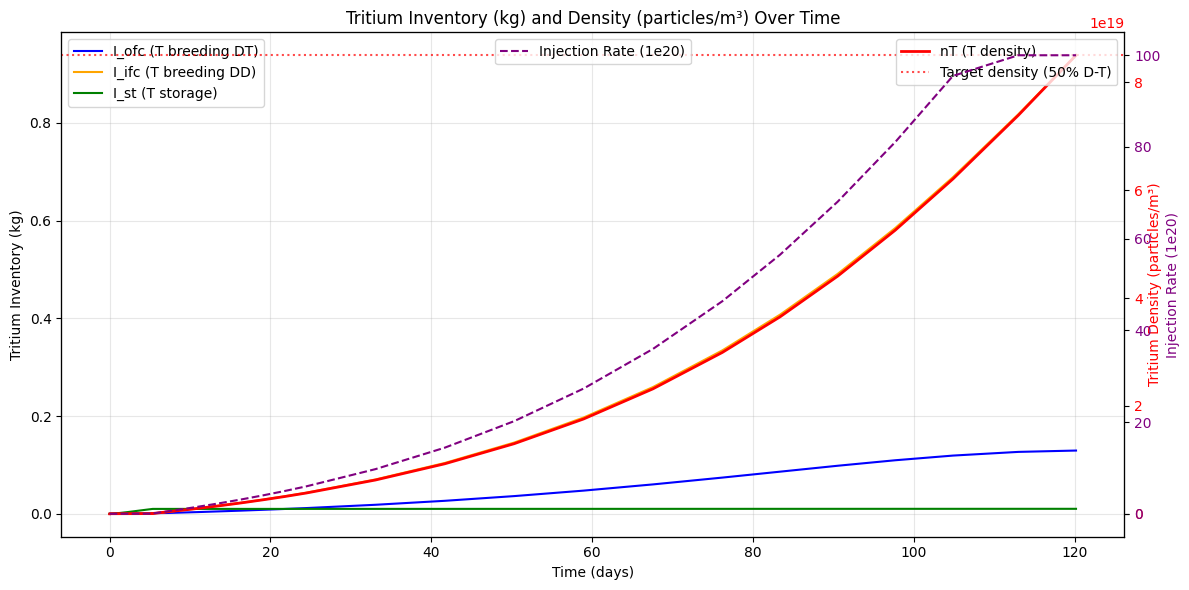

Final tritium inventory: 1.02e-02 kg
Final tritium density: 8.50e+19 particles/m³
Final injection rate: 5.0083847027565595e-05 kg/s
[array([10381416.39384029]), array([], dtype=float64)]
Total time to reach 50% D-T: 120.16 days


In [5]:
# Constants for unit conversion

# plotting the results with dual y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left y-axis: Inventory in kg
ax1.plot(sol1.t/(24*3600), sol1.y[0] * tritium_mass, label='I_ofc (T breeding DT)', color='blue')
ax1.plot(sol1.t/(24*3600), sol1.y[1] * tritium_mass, label='I_ifc (T breeding DD)', color='orange')
ax1.plot(sol1.t/(24*3600), sol1.y[2] * tritium_mass, label='I_st (T storage)', color='green')


ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Tritium Inventory (kg)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')


# Right y-axis: Tritium density in particles/m³
ax2 = ax1.twinx()
ax2.plot(sol1.t/(24*3600), sol1.y[3], label='nT (T density)', color='red', linewidth=2)
ax2.set_ylabel('Tritium Density (particles/m³)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Target density line
ax2.axhline(y=0.5 * ntot, color='red', linestyle=':', alpha=0.7, 
           label='Target density (50% D-T)')
ax2.legend(loc='upper right')

# ax3 injection rate
ax3 = ax1.twinx()
# plot injection rate in kg/s
ax3.plot(sol1.t/(24*3600), [(N_T_in_rate(value)/1e20 ) for value in sol1.y[2]], label='Injection Rate (1e20)', color='purple', linestyle='--')
ax3.set_ylabel('Injection Rate (1e20)', color='purple')
ax3.tick_params(axis='y', labelcolor='purple')
ax3.legend(loc='upper center')

plt.title('Tritium Inventory (kg) and Density (particles/m³) Over Time')
plt.tight_layout()
#plt.xlim(0, 0.3*years_to_seconds)  # Limit x-axis to 10 years
plt.show()

print(f"Final tritium inventory: {sol1.y[2][-1] * tritium_mass:.2e} kg")
print(f"Final tritium density: {sol1.y[3][-1]:.2e} particles/m³")
print("Final injection rate:", N_T_in_rate(sol1.y[2][-1])*tritium_mass, "kg/s")
print(sol1.t_events)
print(f"Total time to reach 50% D-T: {sol1.t_events[0][0]/(24*3600):.2f} days")


# Sensitivity analysis

In [9]:
input_data = [
    V_plasma_field.data.to_base_units().magnitude,           # 0
    T_i_field.data.to('keV').magnitude,                      # 1
    n_tot_field.data.to_base_units().magnitude,              # 2
    tau_p_T_field.data.to_base_units().magnitude,            # 3
    tau_p_He3_field.data.to_base_units().magnitude,          # 4
    P_aux_field.data.to_base_units().magnitude,              # 5
    P_lost_rad_field.data.to_base_units().magnitude,         # 6
    P_aux_all_DT_field.data.to_base_units().magnitude,       # 7
    P_lost_rad_all_DT_field.data.to_base_units().magnitude,  # 8

    tau_ifc_field.data.to_base_units().magnitude,           # 9
    tau_ofc_field.data.to_base_units().magnitude,           # 10

    TBR_DT_field.data.to_base_units().magnitude,       # 11
    TBR_DDn_field.data.to_base_units().magnitude,      # 12

    eta_th_field.data.to_base_units().magnitude,       # 13
    plant_avail_field.data.to_base_units().magnitude,  # 14
    Cost_per_kWh_field.data.to_base_units().magnitude, # 15
]


distr_params = {
    # V_plasma_field.name: cp.Uniform(input_data[0][0], input_data[0][-1]),
    T_i_field.name: cp.Uniform(input_data[1][0], input_data[1][-1]),
    # n_tot_field.name: cp.Uniform(input_data[2][0], input_data[2][-1]),
    tau_p_T_field.name: cp.Uniform(input_data[3][0], input_data[3][-1]),
    # tau_p_He3_field.name: cp.Uniform(input_data[4][0], input_data[4][-1]),
    # P_aux_field.name: cp.Uniform(input_data[5][0], input_data[5][-1]),
    # P_lost_rad_field.name: cp.Uniform(input_data[6][0], input_data[6][-1]),
    # P_aux_all_DT_field.name: cp.Uniform(input_data[7][0], input_data[7][-1]),
    # P_lost_rad_all_DT_field.name: cp.Uniform(input_data[8][0], input_data[8][-1]),
    # tau_ifc_field.name: cp.Uniform(input_data[9][0], input_data[9][-1]),
    # tau_ofc_field.name: cp.Uniform(input_data[10][0], input_data[10][-1]),
    TBR_DT_field.name: cp.Uniform(input_data[11][0], input_data[11][-1]),
    TBR_DDn_field.name: cp.Uniform(input_data[12][0], input_data[12][-1]),
    # eta_th_field.name: cp.Uniform(input_data[13][0], input_data[13][-1]),
    # plant_avail_field.name: cp.Uniform(input_data[14][0], input_data[14][-1]),
    Cost_per_kWh_field.name: cp.Uniform(input_data[15][0], input_data[15][-1]),
}

# print(distr_params)

# Check bounds
# print("\nDistribution bounds:")
# for name, dist in distr_params.items():
#     print(f"{name}: [{dist.lower[0]:.2e}, {dist.upper[0]:.2e}]")

joint_distribution = cp.J(*distr_params.values())

number_of_samples = 100
samples = joint_distribution.sample(number_of_samples, rule="L")
samples_min = samples.min(axis=1, keepdims=True)
samples_max = samples.max(axis=1, keepdims=True)
#scale the samples to [0, 1]
samples_scaled = (samples - samples_min) / (samples_max - samples_min)

print(f"\nSamples shape: {samples.shape}")
print("Sample generation successful!")


Samples shape: (5, 100)
Sample generation successful!


In [7]:
def solve_for_sample(sample):
    # Unpack sample parameters
    # ntot, temp_kev, TBRDT, TBRDD, c_dollar_per_kWh, tau_p_T = sample
    temp_kev, TBRDT, TBRDD, c_dollar_per_kWh, tau_p_T = sample
    # if ntot <= 0 or temp_kev <= 0 or TBRDT <= 0 or TBRDD <= 0:
    #     return {'success': False, 'error': 'Unphysical parameter'}
    Vp = 150
    ntot = 1.7e20  # total density
    # tau_p_T = 0.1
    eta_th = 0.3
    P_aux = 100 # MW

    sigmavDT = sigmav_DT_BoschHale(temp_kev)
    sigmavDDn = sigmav_DD_BoschHale(temp_kev)[2]
    sigmavDDp = sigmav_DD_BoschHale(temp_kev)[1]

    tritium_mass = 3.016049268e-3 / 6.022e23  # kg per tritium atom

    tau_ofc = 3600*24 # hours
    tau_ifc = 3600*12 # hours

    C_f = 0.7 # capacity factor [-]

    MeV_to_J = 1.6022e-13

    # Energy released by fusion reactions
    E_DDp = 4.03*MeV_to_J # [J] energy released by DDp reactions
    E_DDn = 3.46*MeV_to_J # [J] energy released by DDn reactions
    E_DT = 17.6*MeV_to_J # [J] energy released by DT reactions

    lambda_T = 1.78e-9

    injection_rate_max = (ntot/2/tau_p_T*Vp + 0.25*ntot**2*sigmavDT*Vp - 0.25/2*ntot**2*sigmavDDp*Vp)

    def tritium_inventory_odes1(t, y):
        N_ofc, N_ifc, N_st, nT = y
        if N_st < 0.001/tritium_mass:
            injection_rate = 0.0
        else:
            injection_rate = min((N_ifc/tau_ifc - lambda_T*N_st), injection_rate_max)
        # print(injection_rate)
        nD = (ntot - nT)
        dN_ofc_dt = TBRDT*nD*nT*sigmavDT*Vp + TBRDD*0.5*nD**2*sigmavDDn*Vp - N_ofc / tau_ofc - N_ofc*lambda_T
        dN_ifc_dt = N_ofc / tau_ofc - N_ifc / tau_ifc  - lambda_T * N_ifc + nT / tau_p_T * Vp
        dN_stor_dt = N_ifc / tau_ifc - lambda_T * N_st - max(injection_rate,0)
        dnT_dt = injection_rate/Vp + 0.5*nD**2*sigmavDDp - nT/tau_p_T - nD*nT*sigmavDT
        return [dN_ofc_dt, dN_ifc_dt, dN_stor_dt, dnT_dt]

    y0 = [0.0, 0.0, 0.0, 0.0] 
    years_to_seconds = 365 * 24 * 3600
    t_span = (0, 10*years_to_seconds)
    t_eval = np.linspace(*t_span, 10)

    def DT_reached(t, y):
        return y[3] - (0.5 * ntot)
    def NEGATIVE(t, y):
        return min(y[0]+100, y[1]+100, y[2]+100, y[3]+100)
    DT_reached.terminal = True
    NEGATIVE.terminal = True

    try:
        sol = solve_ivp(tritium_inventory_odes1, t_span, y0, method='BDF', events=[DT_reached, NEGATIVE], dense_output=False)
        if sol.t_events[0].size > 0:
            startup_time = sol.t_events[0][0]
        else:
            startup_time = np.nan
        n_D = ntot - sol.y[3][-1]  # deuterium density
        n_T = sol.y[3][-1]
        rate_DT = n_D * n_T * sigmavDT  # [1/s]
        rate_DDp = 0.5 * n_D**2 * sigmavDDp  # [1/s]
        rate_DDn = 0.5 * n_D**2 * sigmavDDn  # [1/s]
        P_e_net_DT = eta_th * (E_DT * rate_DT) - P_aux*1e6  # W
        P_e_net_DD = eta_th * (E_DDp * rate_DDp + E_DDn * rate_DDn) - P_aux*1e6  # W
        E_lost = (P_e_net_DT - P_e_net_DD)*startup_time*C_f
        Ws_into_kWh = 1e-3 / 3600  # convert Ws to kWh
        E_lost = E_lost * Ws_into_kWh # kWh
        G_profit_loss = c_dollar_per_kWh * E_lost # unrealized gain
        return {'success': sol.success, 'injection_rate_max': injection_rate_max, 'solution': sol, 'n_T': n_T, 'startup_time': startup_time, "unrealized_gain": G_profit_loss, "sigmavDT": sigmavDT, "sigmavDDp": sigmavDDp, "sigmavDDn": sigmavDDn, "sample": sample}
    except Exception as e:
        return {'success': False, 'error': str(e)}

In [11]:
# Sobol analysis with PCE using chaospy

# Define the model function for chaospy (returns a scalar output, e.g., final tritium inventory)
# def model_func(*params):
#     result = solve_for_sample(params)
#     if result['success']:
#         # sol = result['solution']
#         G_profit_loss = result["unrealized_gain"]
#         return G_profit_loss
#     else:
#         return np.nan  # or some default value for failed runs
        # print("Failed sample:", samples[:, i])
        # print("Error:", result['error'])

# Generate polynomial basis for PCE
order = 4  # You can increase for higher accuracy
poly_expansion = cp.generate_expansion(order, joint_distribution)

negative_inventory_failures = 0
nan_startup_time_failures = 0
other_failures = 0

# Evaluate model for all samples with progress printing
print(f"\nEvaluating model for {samples.shape[1]} samples (for PCE fit)...")
model_outputs = []
start_time = time.time()
for i in range(samples.shape[1]):
    if i % (number_of_samples//100) == 0:
        elapsed = time.time() - start_time
        if i > 0:
            estimated_remaining = (elapsed / i) * (samples.shape[1] - i)
            print(f"Processed {i}/{samples.shape[1]} samples ({i/samples.shape[1]*100:.0f}%) - "
                  f"Elapsed: {elapsed:.1f}s - "
                  f"ETA: {estimated_remaining:.1f}s   ", end='\r')
        else:
            print(f"\nStarting PCE model evaluation...")

    result = solve_for_sample(samples[:, i])
    # if i == 0:
    #     print("sigmav_DT = ", result["sigmavDT"], "sigmav_DDp = ", result["sigmavDDp"], "sigmav_DDn = ", result["sigmavDDn"])
    #     print("startup time = ", result["startup_time"] / (3600*24), "days")
    #     print("n_T = ", result["n_T"])
    #     print("injection_rate_max = ", result["injection_rate_max"])
    #     print("unrealized gain = ", result["unrealized_gain"]/1e9, "billion $")
    #     print()
    #     print("Sample = ", result["sample"])
        # break
    if not result['success']:
        if 'negative' in str(result.get('error', '')).lower():
            negative_inventory_failures += 1
        else:
            other_failures += 1
        model_outputs.append(np.nan)
    else:
        if np.isnan(result['startup_time']):
            nan_startup_time_failures += 1
            model_outputs.append(np.nan)
        else:
            model_outputs.append(result["unrealized_gain"])
    # model_outputs.append(model_func(*samples[:, i]))

model_outputs = np.array(model_outputs)
total_time = time.time() - start_time
print(f"\nModel evaluation for PCE completed!")
print(f"Negative inventory failures: {negative_inventory_failures}")
print(f"Other failures: {other_failures}")
print(f"Total failures: {negative_inventory_failures + other_failures}")
print(f"Runs where startup_time is NaN: {nan_startup_time_failures}")
print(f"Total time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
print(f"Average time per sample: {total_time/samples.shape[1]:.3f} seconds")

print(f"Model outputs: {model_outputs}")

# Filter out nan values
valid_mask = ~np.isnan(model_outputs)
filtered_outputs = model_outputs[valid_mask]
filtered_samples_scaled = samples_scaled[:, valid_mask]
print(f"Valid samples for PCE fitting: {filtered_samples_scaled.shape[1]} out of {samples.shape[1]}")

# Fit PCE surrogate model
pce_model = cp.fit_regression(poly_expansion, filtered_samples_scaled, filtered_outputs)
print("PCE surrogate model fitted.")

# Compute first-order Sobol indices
sobol_first = cp.Sens_m(pce_model, joint_distribution)
print("First-order Sobol indices computed.")

# Compute total-order Sobol indices
sobol_total = cp.Sens_t(pce_model, joint_distribution)
print("Total-order Sobol indices computed.")

# Print Sobol indices for each input parameter
for i, param_name in enumerate(distr_params.keys()):
    print(f"{param_name}: First-order = {sobol_first[i]:.4f}, Total-order = {sobol_total[i]:.4f}")



Evaluating model for 100 samples (for PCE fit)...

Starting PCE model evaluation...
Processed 99/100 samples (99%) - Elapsed: 4.3s - ETA: 0.0s   
Model evaluation for PCE completed!
Negative inventory failures: 0
Other failures: 7
Total failures: 7
Runs where startup_time is NaN: 93
Total time: 4.4 seconds (0.1 minutes)
Average time per sample: 0.044 seconds
Model outputs: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]
Valid samples for PCE fitting: 0 out of 100
PCE surrogate model fitted.
First-order Sobol indices computed.
Total-order Sobol indices computed.
T_i_field: First-order = 0.0000, Total-order = 0.0000
tau_p_T: First-ord

## Debugging and result visualization

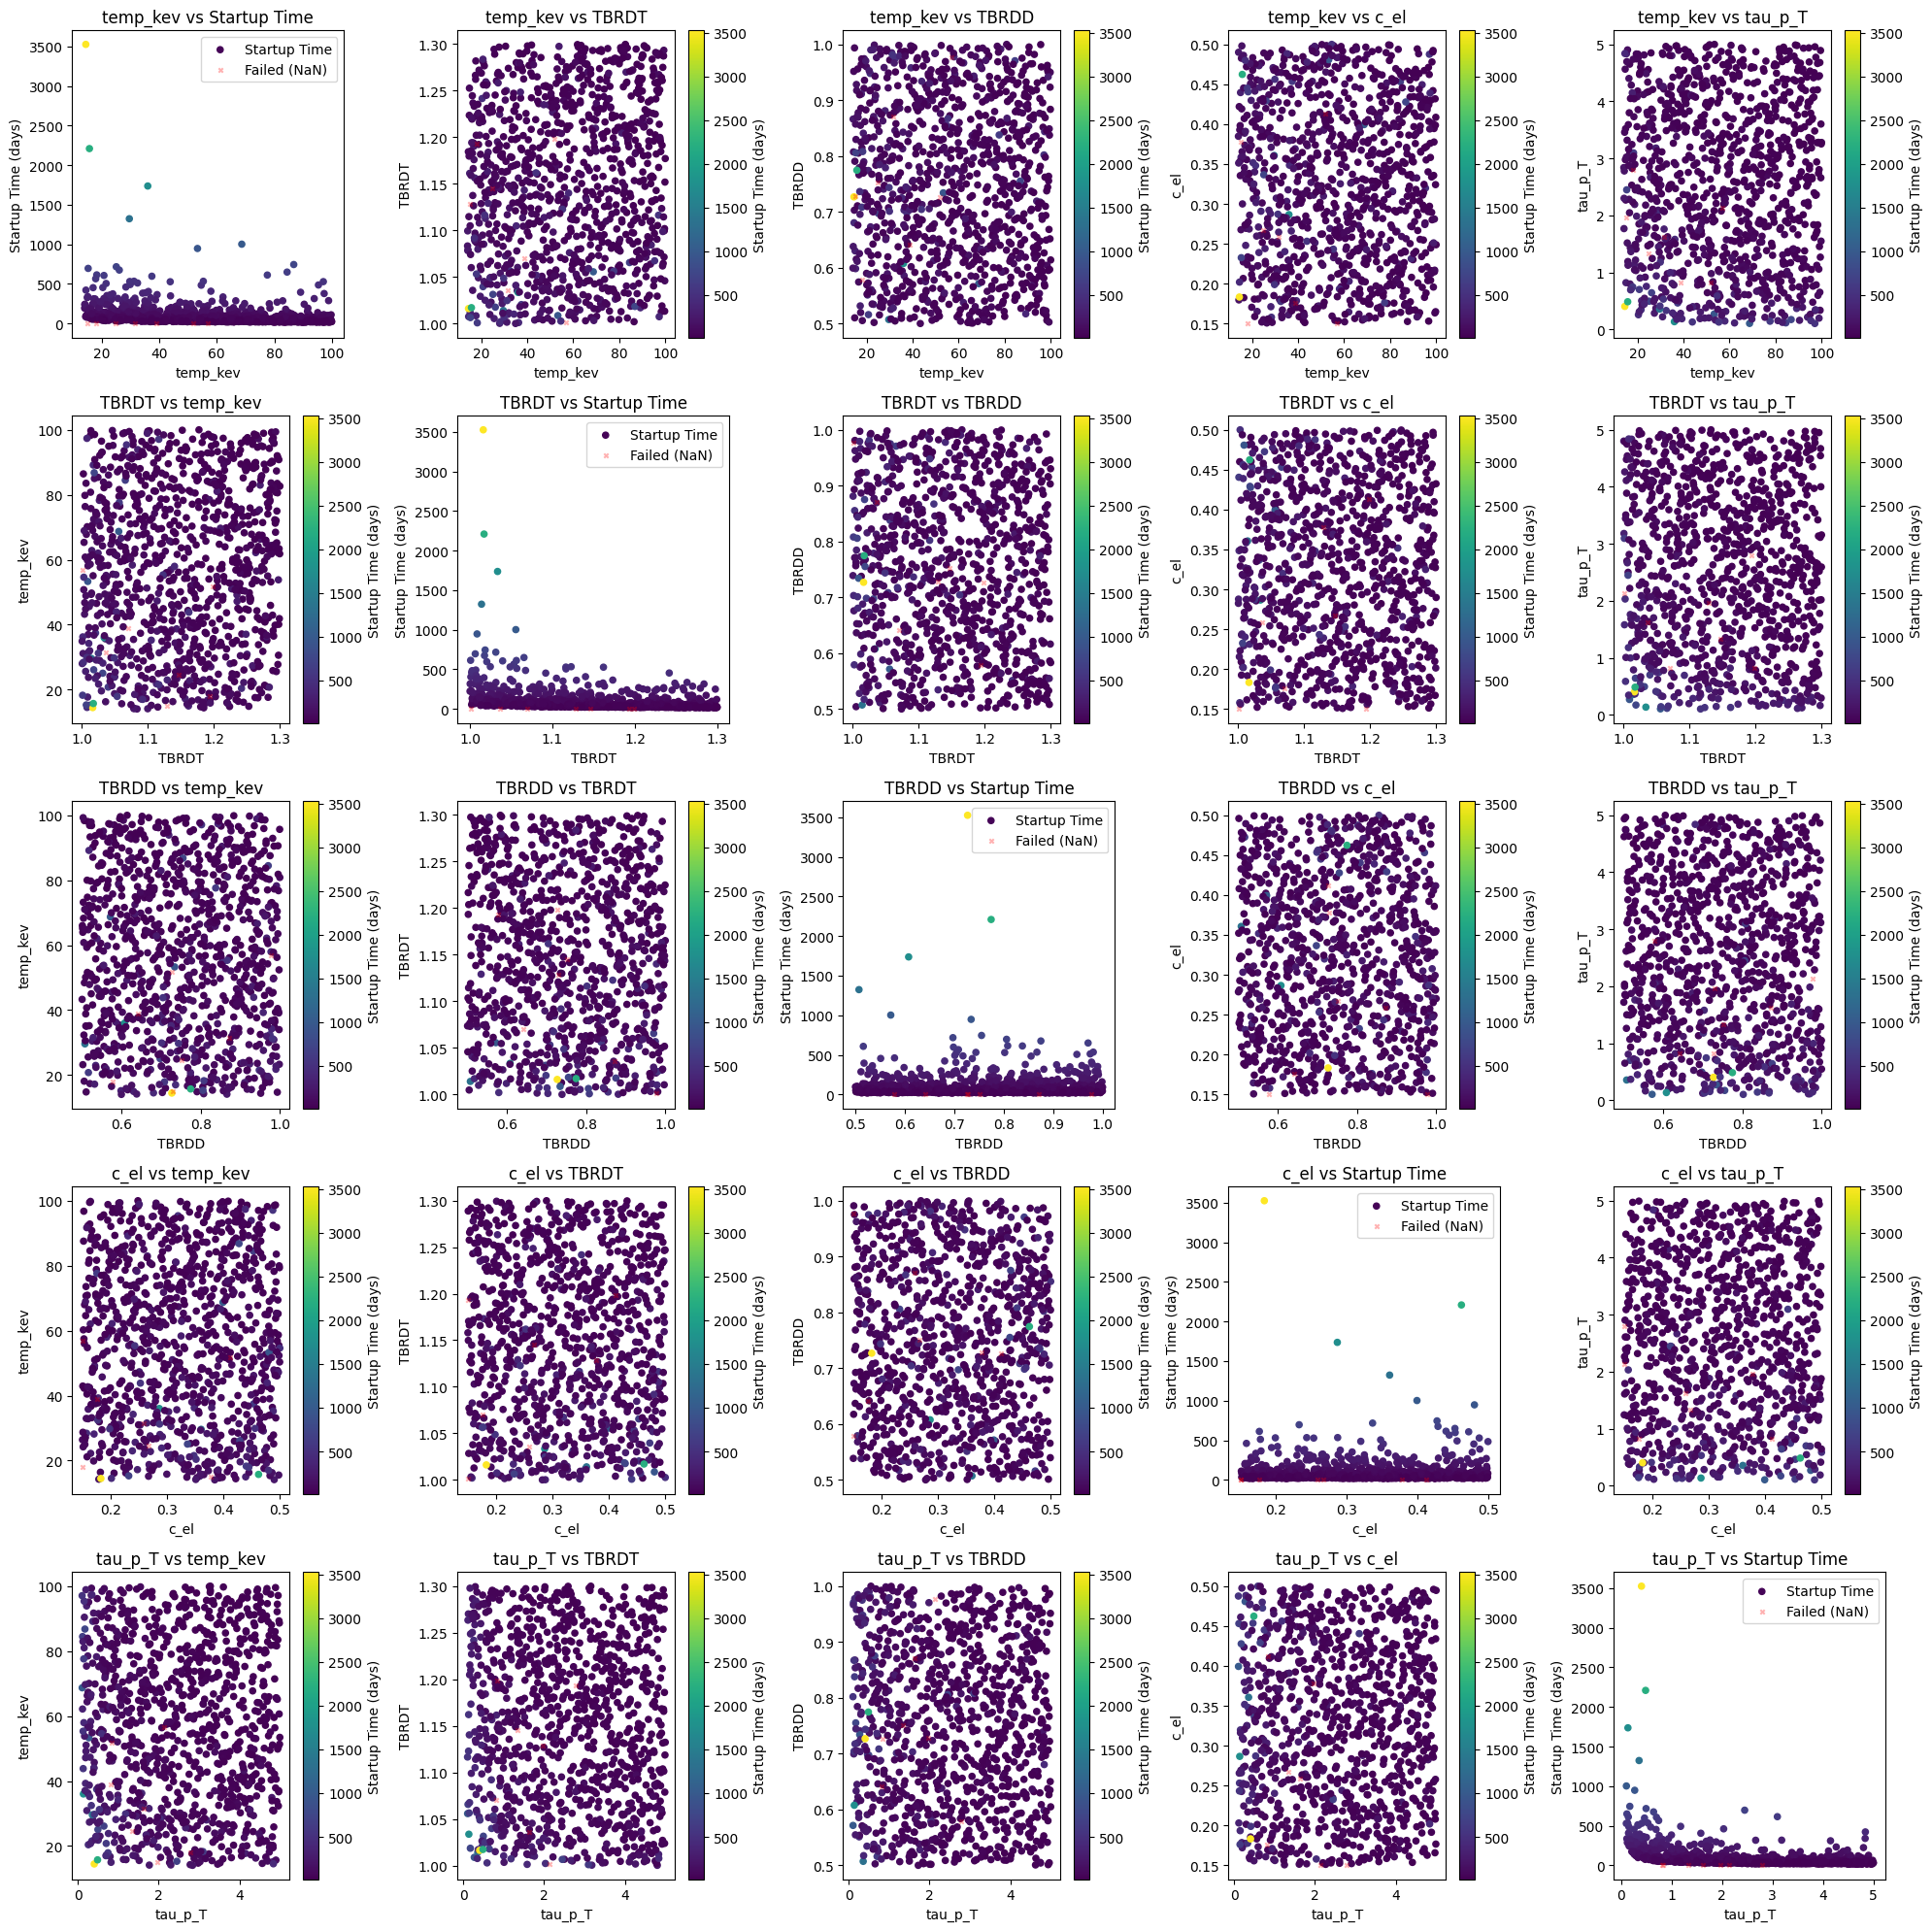

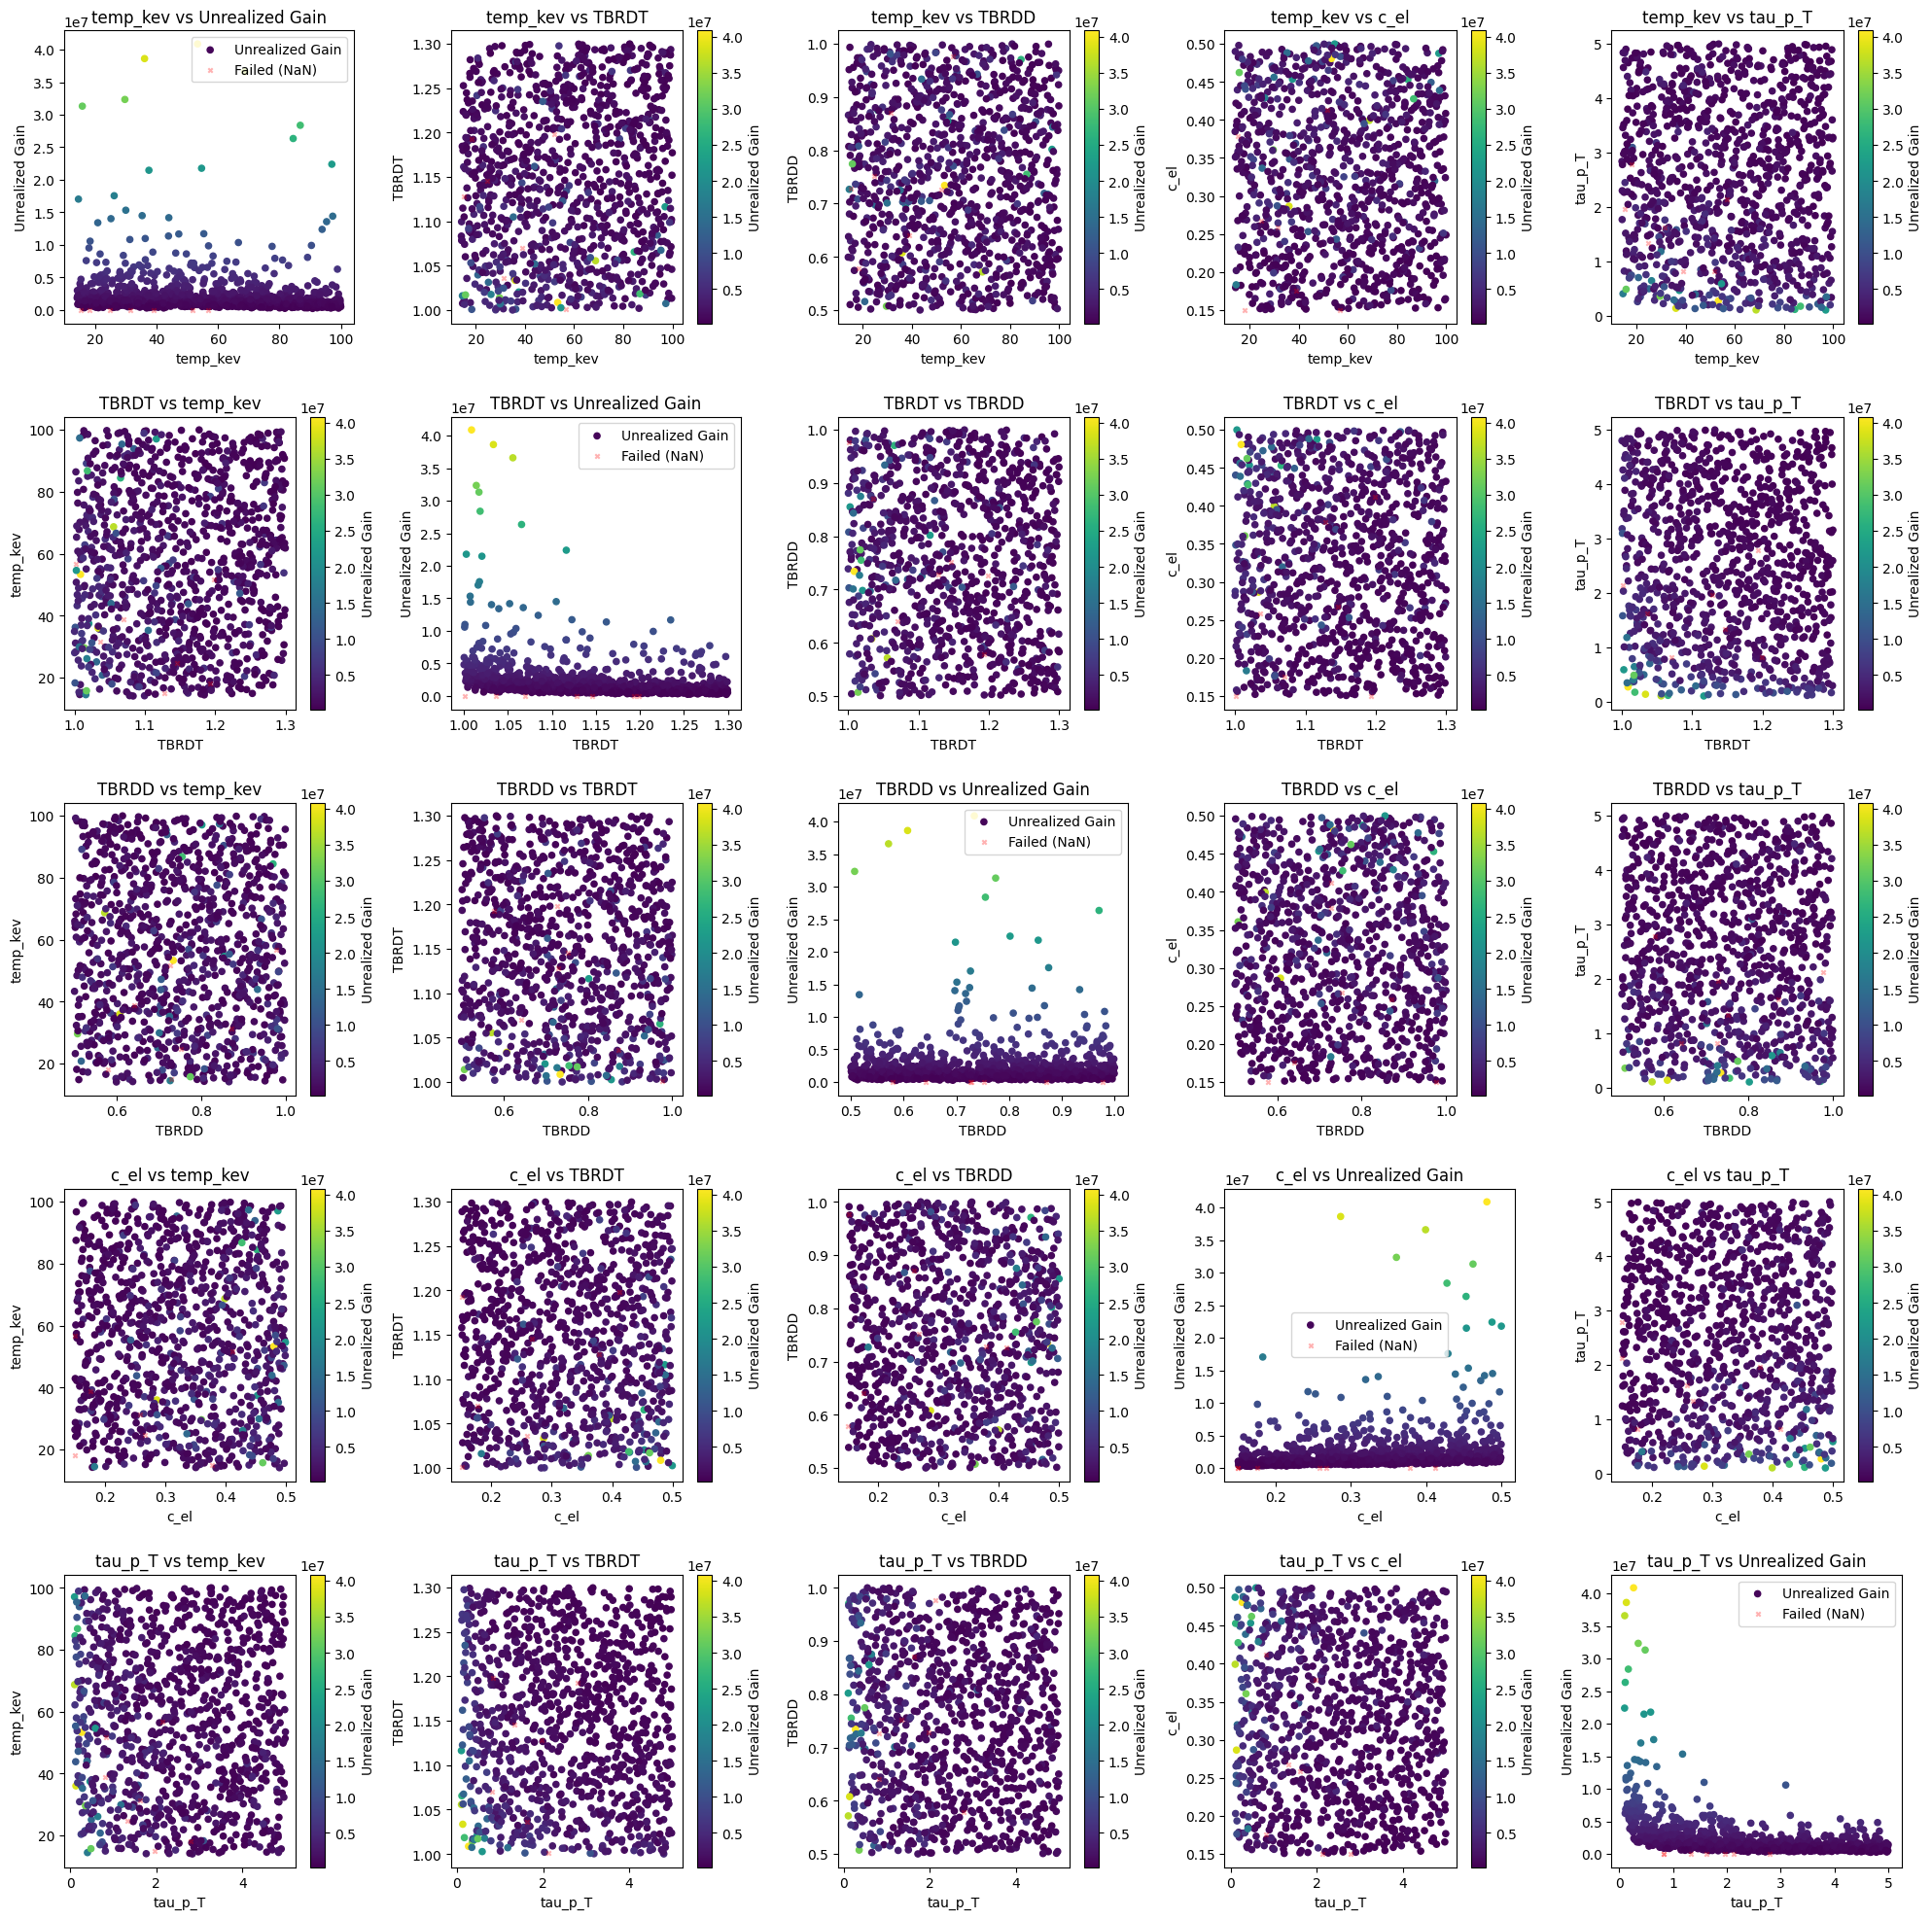

In [ ]:
import matplotlib.pyplot as plt

number_of_samples = 1000
samples = joint_distribution.sample(number_of_samples, rule="L")

# Collect startup times and indices for all samples
startup_times = []
unrealized_gains = []
for i in range(samples.shape[1]):
    result = solve_for_sample(samples[:, i])
    if result['success']:
        startup_times.append(result['startup_time'] / (24*3600) if not np.isnan(result['startup_time']) else np.nan)
        unrealized_gains.append(result['unrealized_gain'] if not np.isnan(result['unrealized_gain']) else np.nan)
    else:
        startup_times.append(np.nan)
        unrealized_gains.append(np.nan)
startup_times = np.array(startup_times)
unrealized_gains = np.array(unrealized_gains)

param_names = list(distr_params.keys())
n_params = len(param_names)
samples_arr = np.array(samples)

fig, axes = plt.subplots(n_params, n_params, figsize=(4*n_params, 4*n_params), squeeze=False)

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]
        if i == j:
            # Diagonal: 1D scatter plot
            mask_valid = ~np.isnan(startup_times)
            ax.scatter(samples_arr[i, mask_valid], startup_times[mask_valid],
                       c=startup_times[mask_valid], cmap='viridis', s=20, label='Startup Time')
            mask_nan = np.isnan(startup_times)
            ax.scatter(samples_arr[i, mask_nan], [0]*np.sum(mask_nan),
                       color='red', marker='x', s=10, alpha=0.3, label='Failed (NaN)')
            ax.set_xlabel(param_names[i])
            ax.set_ylabel('Startup Time (days)')
            ax.set_title(f'{param_names[i]} vs Startup Time')
        else:
            # Off-diagonal: 2D scatter plot
            mask_valid = ~np.isnan(startup_times)
            sc = ax.scatter(samples_arr[i, mask_valid], samples_arr[j, mask_valid],
                            c=startup_times[mask_valid], cmap='viridis', s=20, label='Startup Time')
            mask_nan = np.isnan(startup_times)
            ax.scatter(samples_arr[i, mask_nan], samples_arr[j, mask_nan],
                       color='red', marker='x', s=10, alpha=0.3, label='Failed (NaN)')
            ax.set_xlabel(param_names[i])
            ax.set_ylabel(param_names[j])
            ax.set_title(f'{param_names[i]} vs {param_names[j]}')
        if i != j:
            plt.colorbar(sc, ax=ax, label='Startup Time (days)')
        if i == j:
            ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_params, n_params, figsize=(4*n_params, 4*n_params), squeeze=False)

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]
        if i == j:
            # Diagonal: 1D scatter plot
            mask_valid = ~np.isnan(unrealized_gains)
            ax.scatter(samples_arr[i, mask_valid], unrealized_gains[mask_valid],
                       c=unrealized_gains[mask_valid], cmap='viridis', s=20, label='Unrealized Gain')
            mask_nan = np.isnan(unrealized_gains)
            ax.scatter(samples_arr[i, mask_nan], [0]*np.sum(mask_nan),
                       color='red', marker='x', s=10, alpha=0.3, label='Failed (NaN)')
            ax.set_xlabel(param_names[i])
            ax.set_ylabel('Unrealized Gain')
            ax.set_title(f'{param_names[i]} vs Unrealized Gain')
        else:
            # Off-diagonal: 2D scatter plot
            mask_valid = ~np.isnan(unrealized_gains)
            sc = ax.scatter(samples_arr[i, mask_valid], samples_arr[j, mask_valid],
                            c=unrealized_gains[mask_valid], cmap='viridis', s=20, label='Unrealized Gain')
            mask_nan = np.isnan(unrealized_gains)
            ax.scatter(samples_arr[i, mask_nan], samples_arr[j, mask_nan],
                       color='red', marker='x', s=10, alpha=0.3, label='Failed (NaN)')
            ax.set_xlabel(param_names[i])
            ax.set_ylabel(param_names[j])
            ax.set_title(f'{param_names[i]} vs {param_names[j]}')
        if i != j:
            plt.colorbar(sc, ax=ax, label='Unrealized Gain')
        if i == j:
            ax.legend()
plt.tight_layout()
plt.show()